In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'axes.titlesize': 12, 'axes.labelsize': 10})

In [3]:
FILE_PATH = '/content/drive/MyDrive/CSE437/Project/bd_students_per_v2 (1).csv'
df = pd.read_csv(FILE_PATH)
print(f'Dataset shape: {df.shape[0]} rows x {df.shape[1]} columns')
df.head()

Dataset shape: 8612 rows x 24 columns


,id,full_name,age,gender,location,family_size,mother_education,father_education,mother_job,father_job,...,tutoring,school_type,attendance,extra_curricular_activities,english,math,science,social_science,art_culture,stu_group
0,2,Avi Biswas,16,Male,Urban,6,SSC,HSC,No,No,...,Yes,Private,95,Yes,95,98,92,94,98,Science
1,3,Taslima Sultana,18,Female,Rural,6,SSC,HSC,No,Yes,...,No,Semi_Govt,92,No,65,71,40,78,80,Commerce
2,4,Md Adilur Rahman,15,Male,Rural,4,SSC,SSC,Yes,Yes,...,Yes,Govt,81,Yes,64,78,58,86,74,Commerce
3,5,Saleh Ahmed,16,Male,Rural,6,SSC,SSC,Yes,Yes,...,Yes,Private,90,Yes,84,90,85,86,88,Science
4,6,Din Islam,17,Male,Urban,5,Honors,Masters,No,Yes,...,Yes,Semi_Govt,75,Yes,54,70,45,79,76,Commerce


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8612 entries, 0 to 8611
Data columns (total 24 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   id                           8612 non-null   int64 
 1   full_name                    8612 non-null   object
 2   age                          8612 non-null   int64 
 3   gender                       8612 non-null   object
 4   location                     8611 non-null   object
 5   family_size                  8612 non-null   int64 
 6   mother_education             8602 non-null   object
 7   father_education             8608 non-null   object
 8   mother_job                   8612 non-null   object
 9   father_job                   8612 non-null   object
 10  guardian                     8612 non-null   object
 11  parental_involvement         8612 non-null   object
 12  internet_access              8612 non-null   object
 13  studytime                    8612

In [5]:
# Missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
quality_report = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print('=== Missing Value Report ===')
print(quality_report[quality_report['Missing Count'] > 0]
      if quality_report['Missing Count'].sum() > 0
      else 'No missing values detected.')

# Duplicate rows
print(f'\nDuplicate rows: {df.duplicated().sum()}')

=== Missing Value Report ===
                  Missing Count  Missing %
location                      1       0.01
mother_education             10       0.12
father_education              4       0.05

Duplicate rows: 0


In [6]:
# Descriptive statistics — sorted by std dev (most variable features first)
df.describe().T.sort_values(by='std', ascending=False)

,count,mean,std,min,25%,50%,75%,max
id,8612.0,4307.500000,2486.214593,2.0,2154.75,4307.5,6460.25,8613.0
math,8612.0,72.938110,15.816147,33.0,64.00,73.0,84.00,100.0
english,8612.0,73.610427,15.343903,18.0,64.00,75.0,85.00,100.0
science,8612.0,73.524036,15.115104,33.0,63.00,75.0,85.00,100.0
social_science,8612.0,74.465513,14.945846,36.0,65.00,77.0,86.00,100.0
art_culture,8612.0,76.236066,13.619125,36.0,69.00,76.0,86.00,100.0
attendance,8612.0,74.027055,13.290046,30.0,63.00,73.0,86.00,100.0
studytime,8612.0,4.746168,2.185645,1.0,3.00,5.0,6.00,16.0
family_size,8612.0,4.502206,1.656726,0.0,3.00,5.0,6.00,11.0
age,8612.0,16.614375,0.969057,10.0,16.00,17.0,17.00,24.0


In [7]:
# Reorder columns: features first, score columns last
FEATURE_COLS = [
    'id', 'full_name', 'age', 'gender', 'location', 'stu_group', 'family_size',
    'mother_education', 'father_education', 'mother_job', 'father_job',
    'guardian', 'parental_involvement', 'internet_access', 'studytime',
    'tutoring', 'school_type', 'attendance', 'extra_curricular_activities'
]
SCORE_COLS = ['english', 'math', 'science', 'social_science', 'art_culture']

df = df[FEATURE_COLS + SCORE_COLS]
df.head()

,id,full_name,age,gender,location,stu_group,family_size,mother_education,father_education,mother_job,...,studytime,tutoring,school_type,attendance,extra_curricular_activities,english,math,science,social_science,art_culture
0,2,Avi Biswas,16,Male,Urban,Science,6,SSC,HSC,No,...,8,Yes,Private,95,Yes,95,98,92,94,98
1,3,Taslima Sultana,18,Female,Rural,Commerce,6,SSC,HSC,No,...,4,No,Semi_Govt,92,No,65,71,40,78,80
2,4,Md Adilur Rahman,15,Male,Rural,Commerce,4,SSC,SSC,Yes,...,5,Yes,Govt,81,Yes,64,78,58,86,74
3,5,Saleh Ahmed,16,Male,Rural,Science,6,SSC,SSC,Yes,...,7,Yes,Private,90,Yes,84,90,85,86,88
4,6,Din Islam,17,Male,Urban,Commerce,5,Honors,Masters,No,...,4,Yes,Semi_Govt,75,Yes,54,70,45,79,76


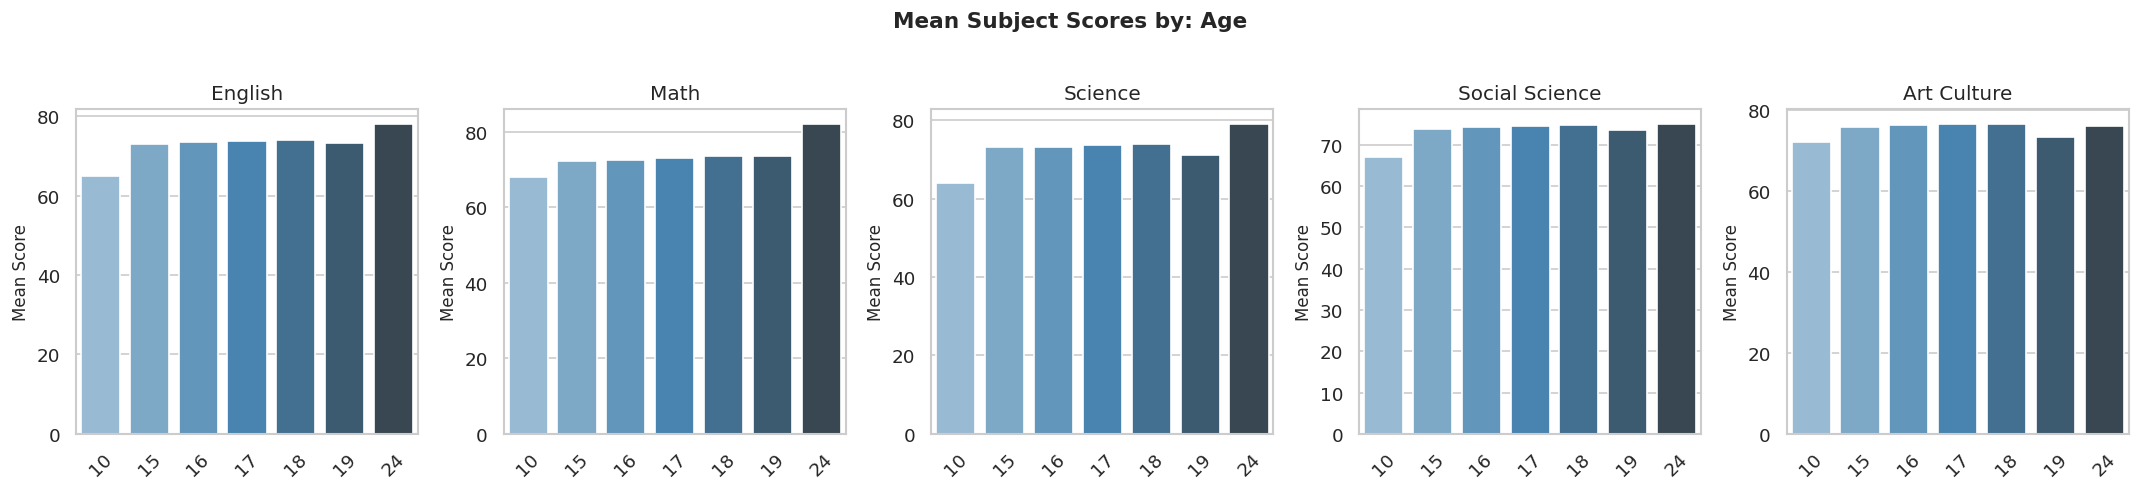

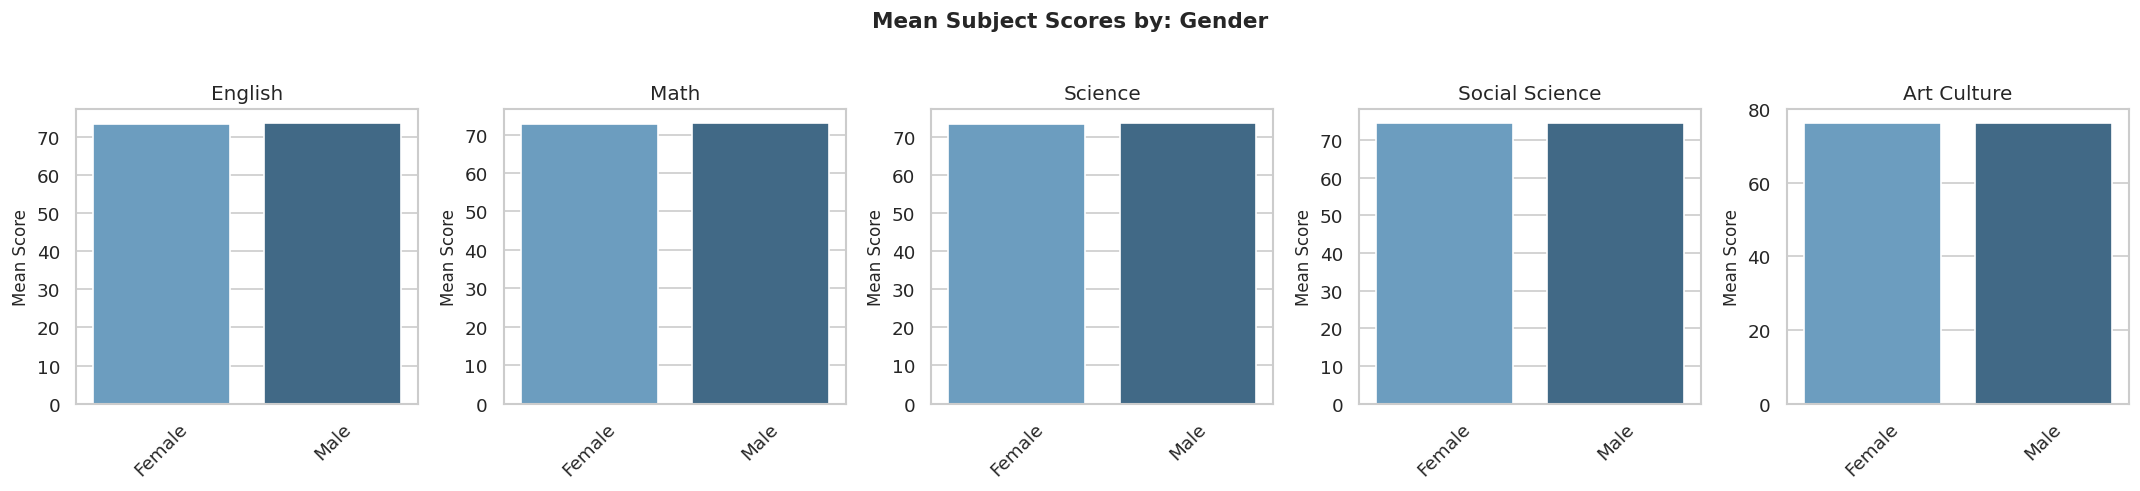

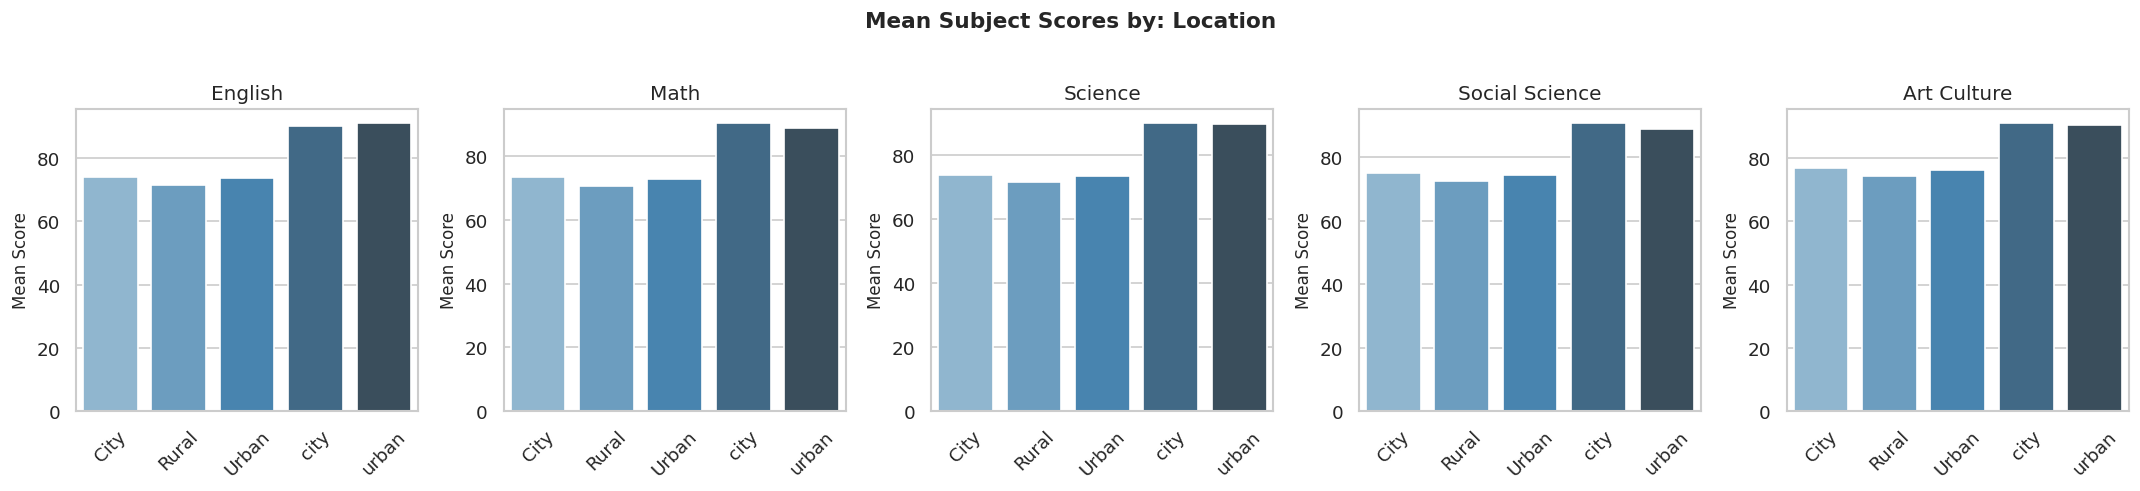

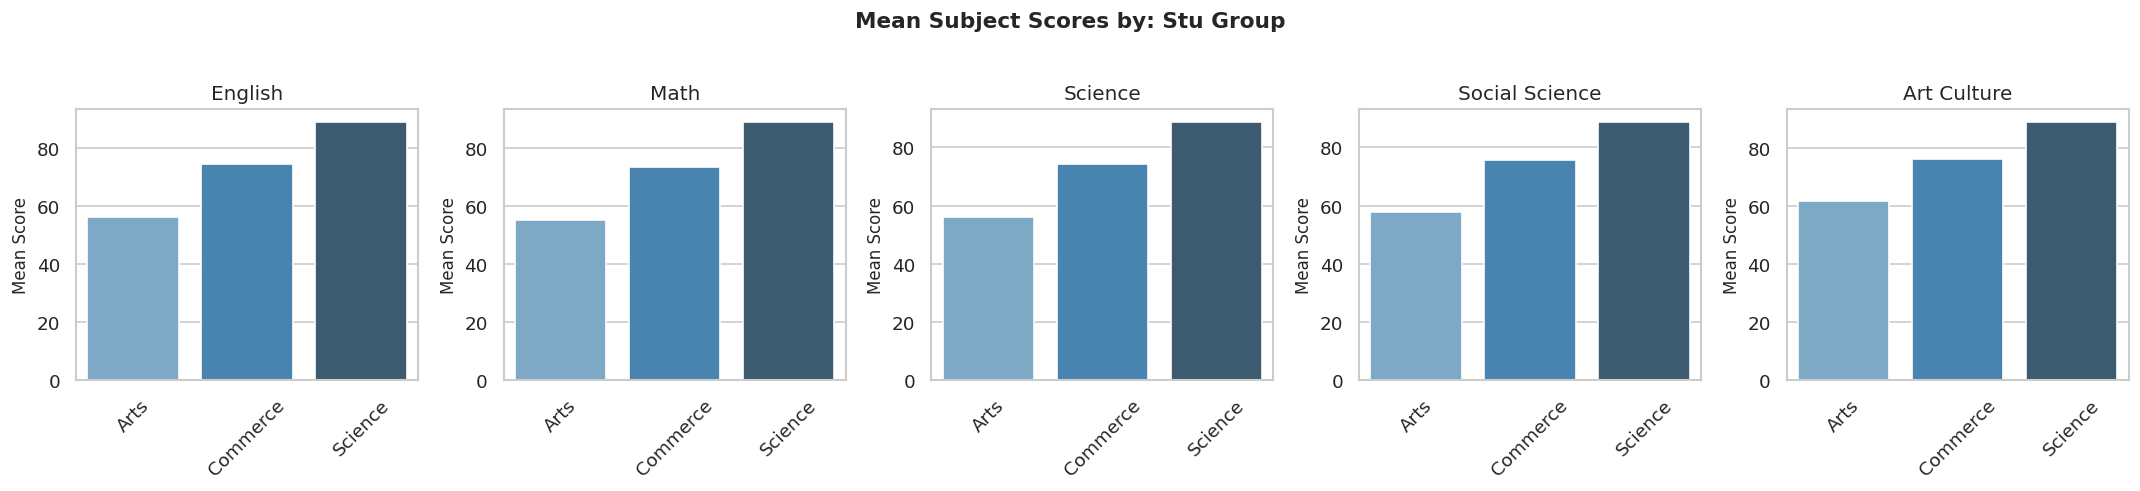

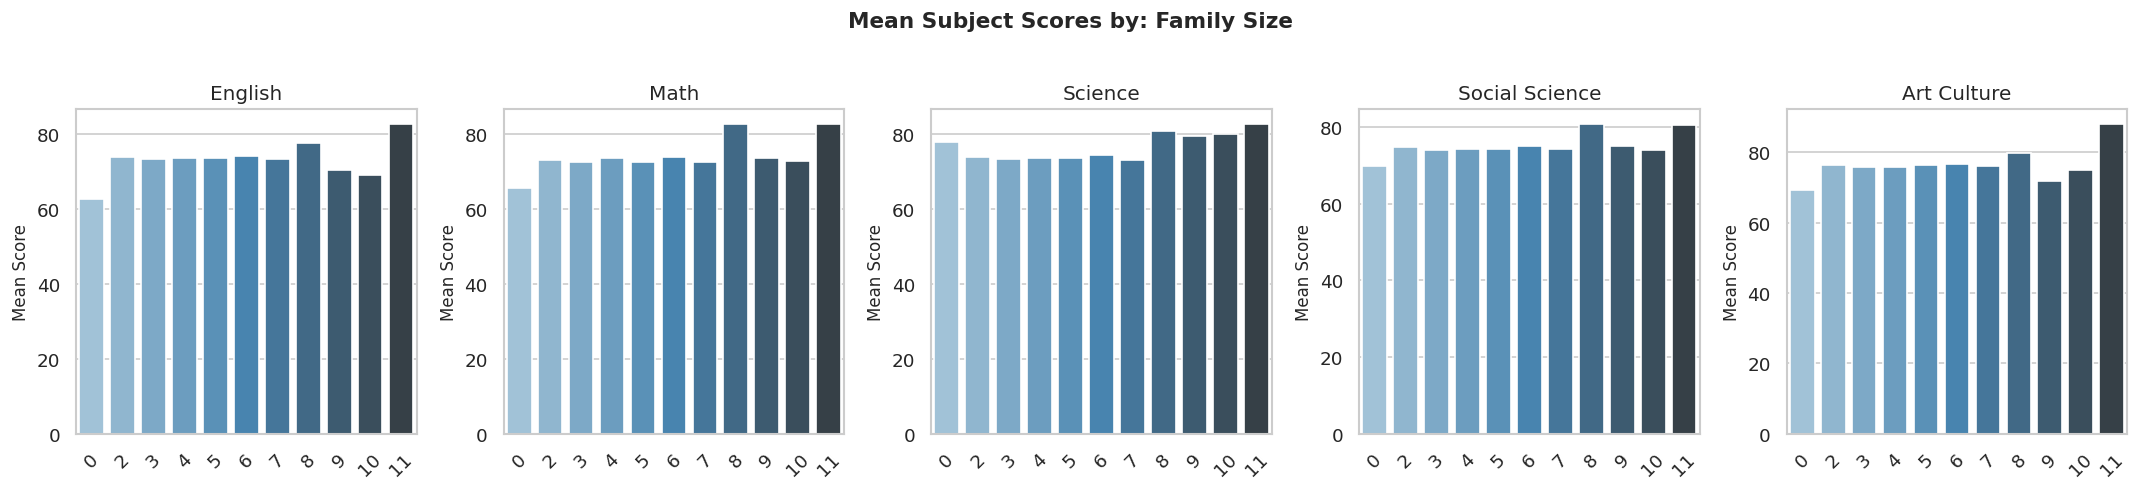

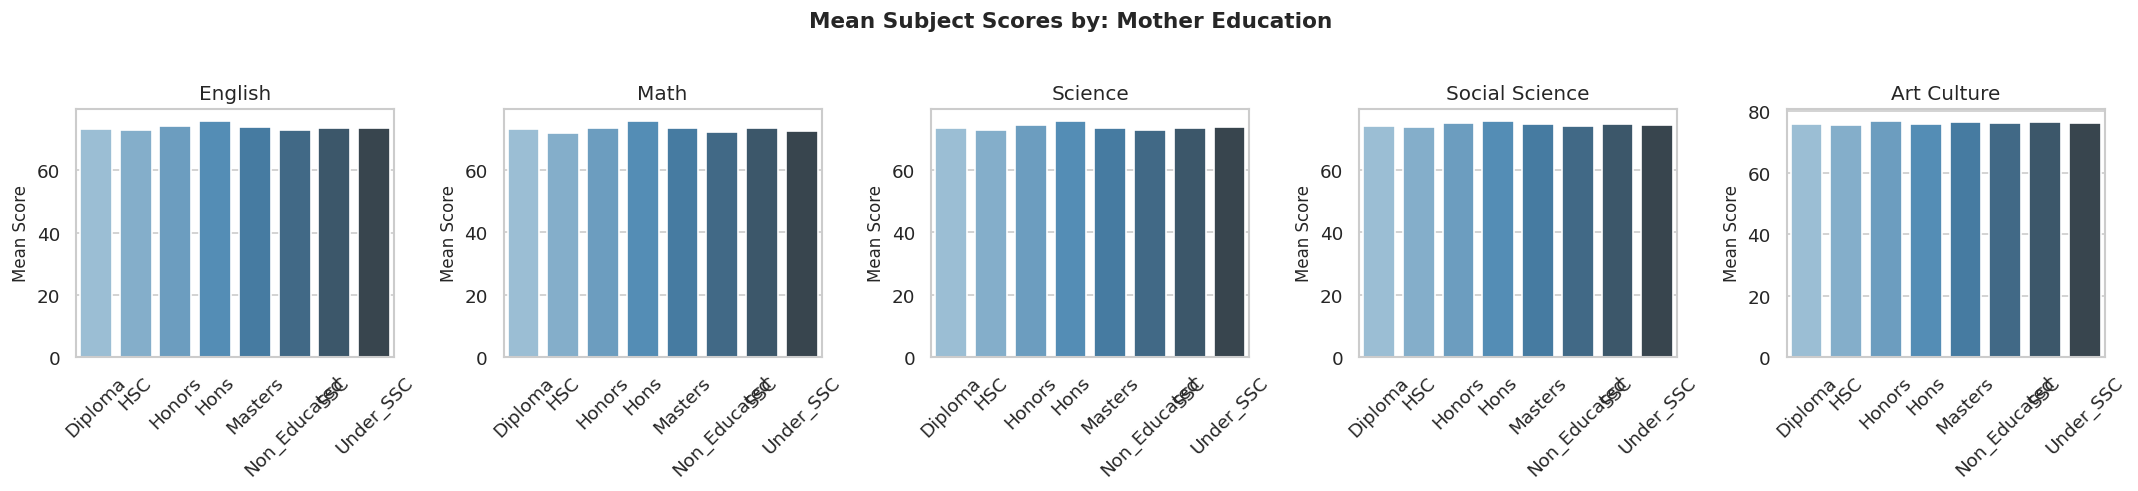

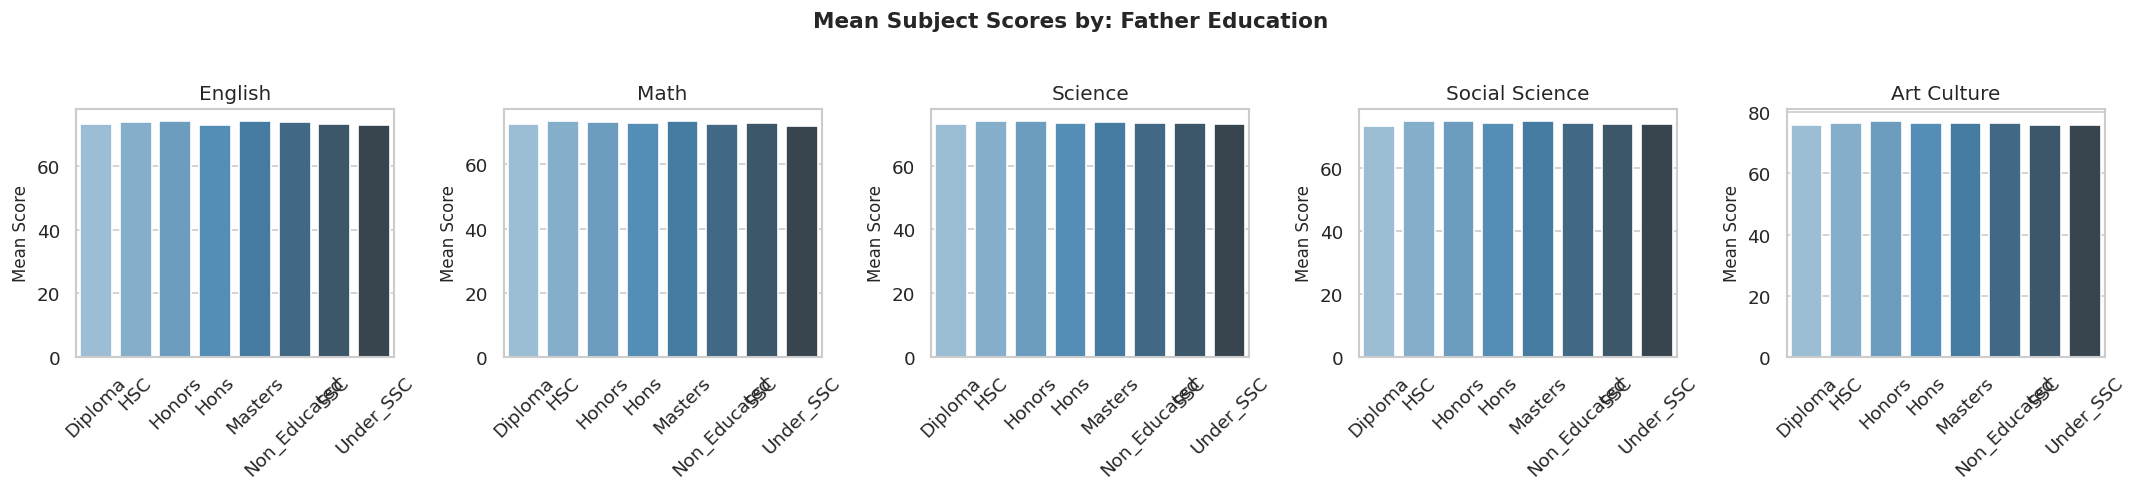

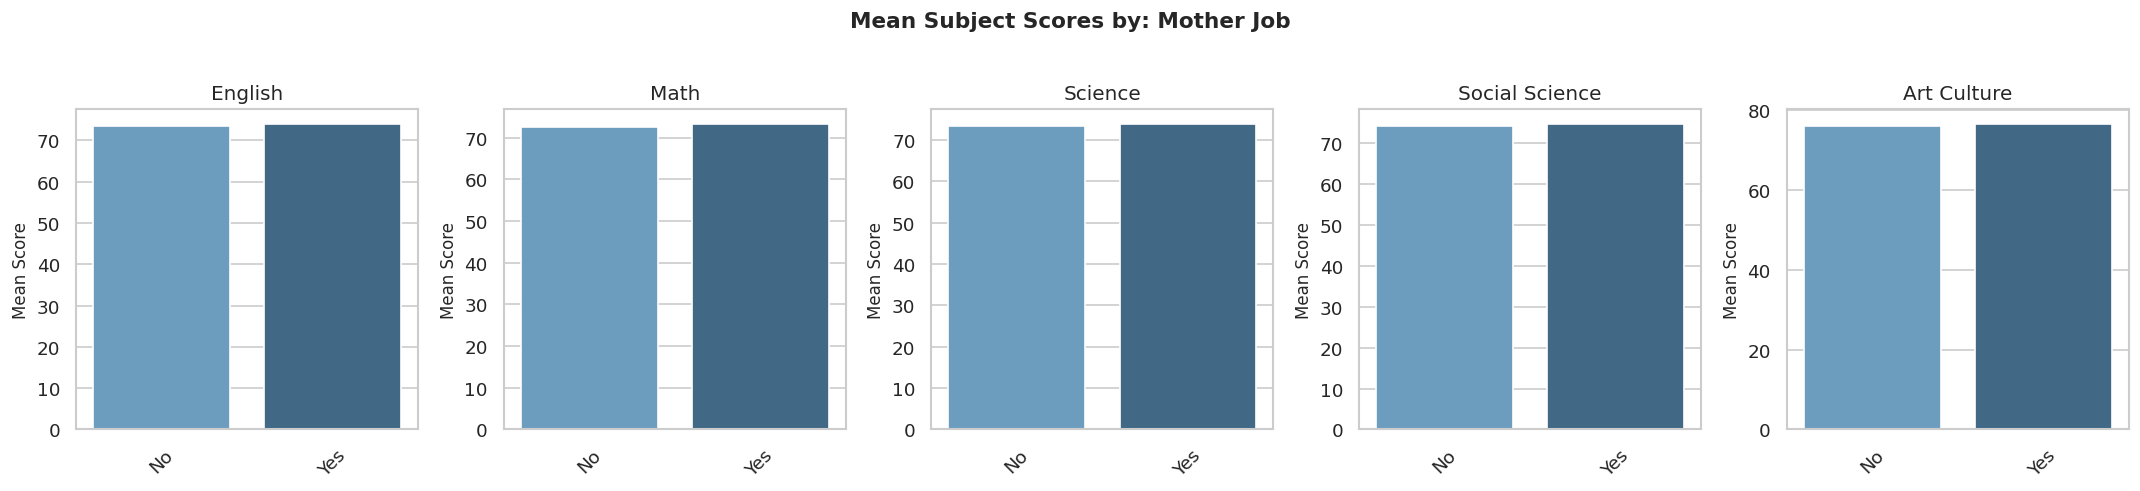

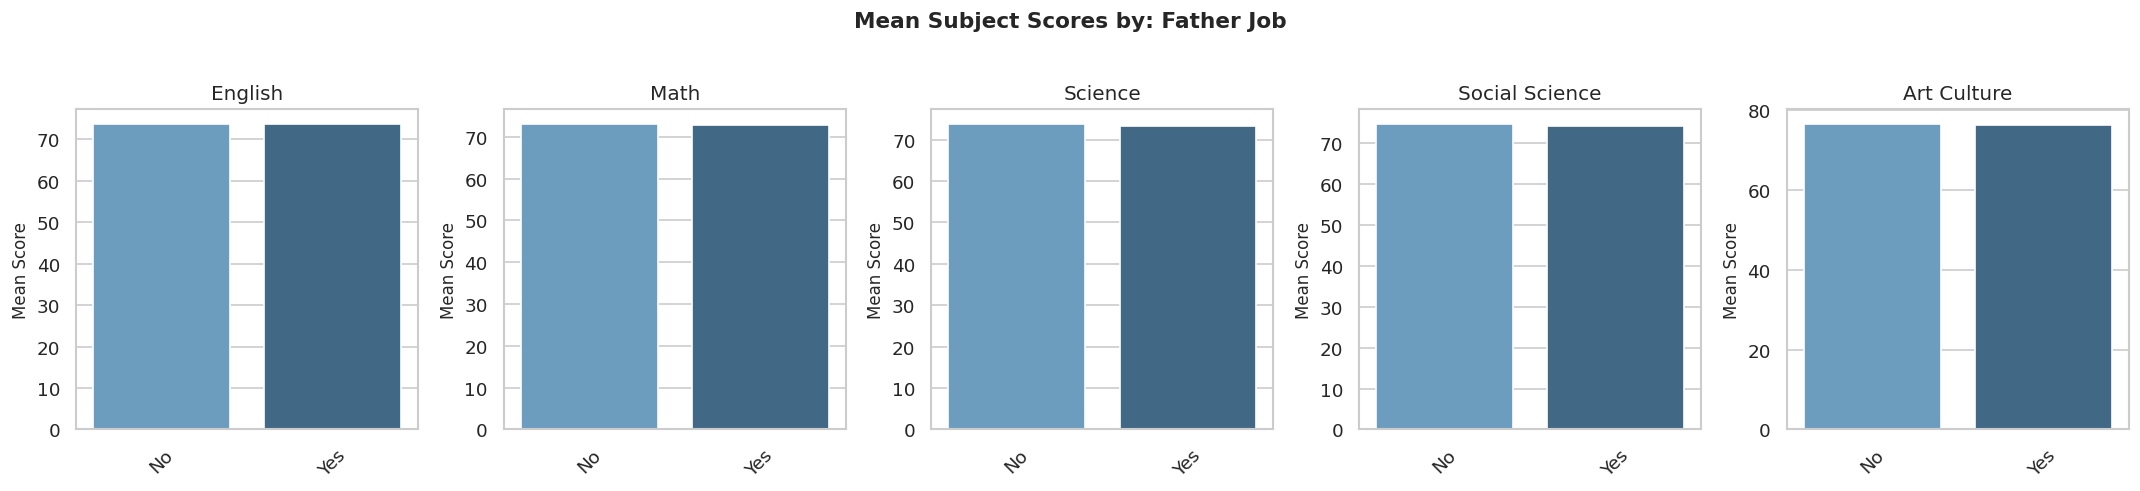

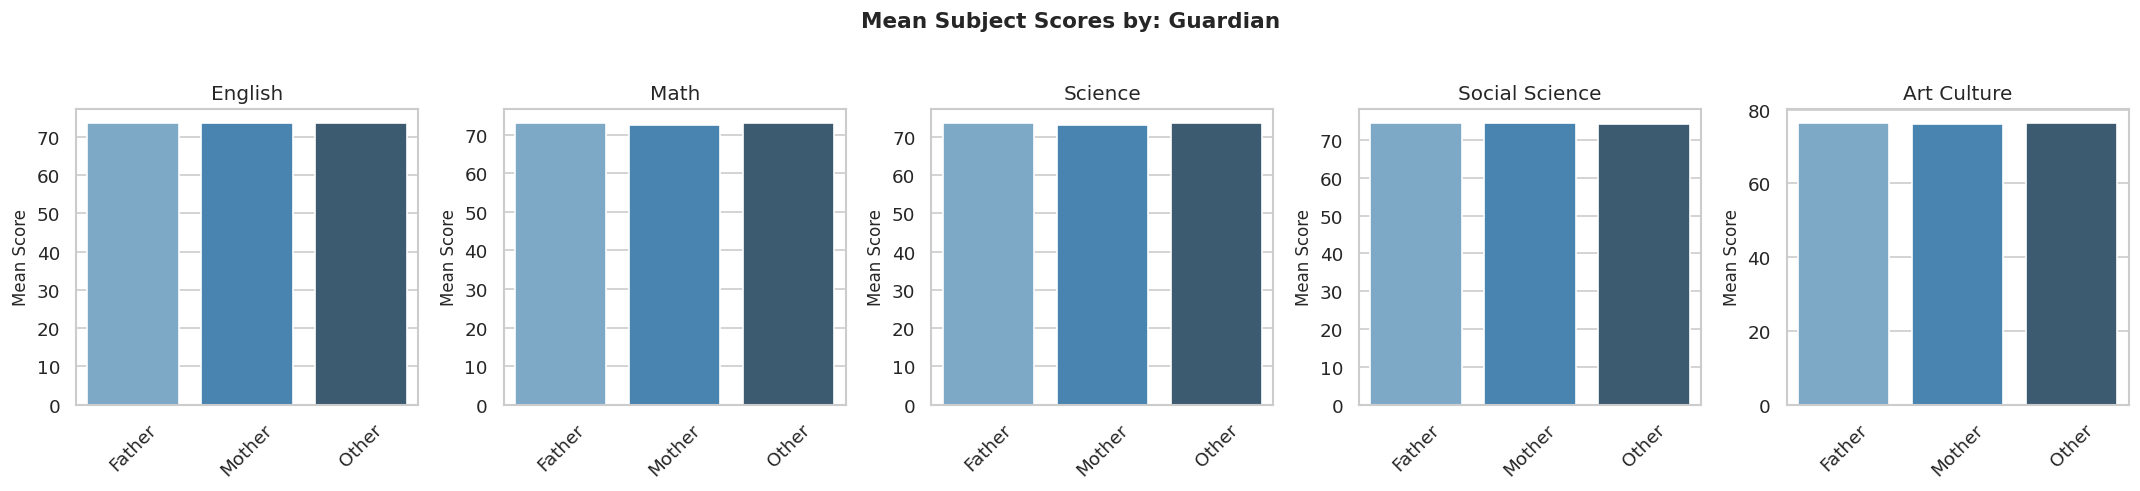

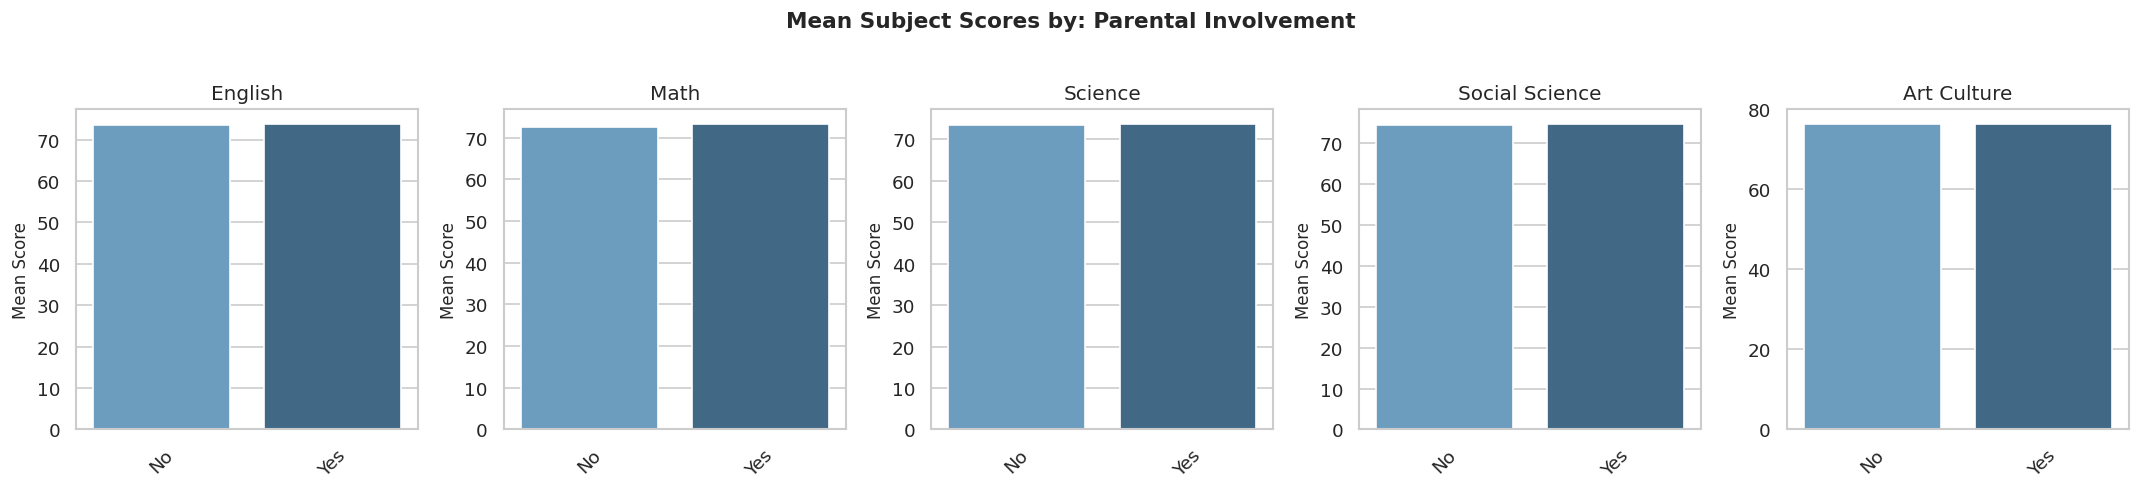

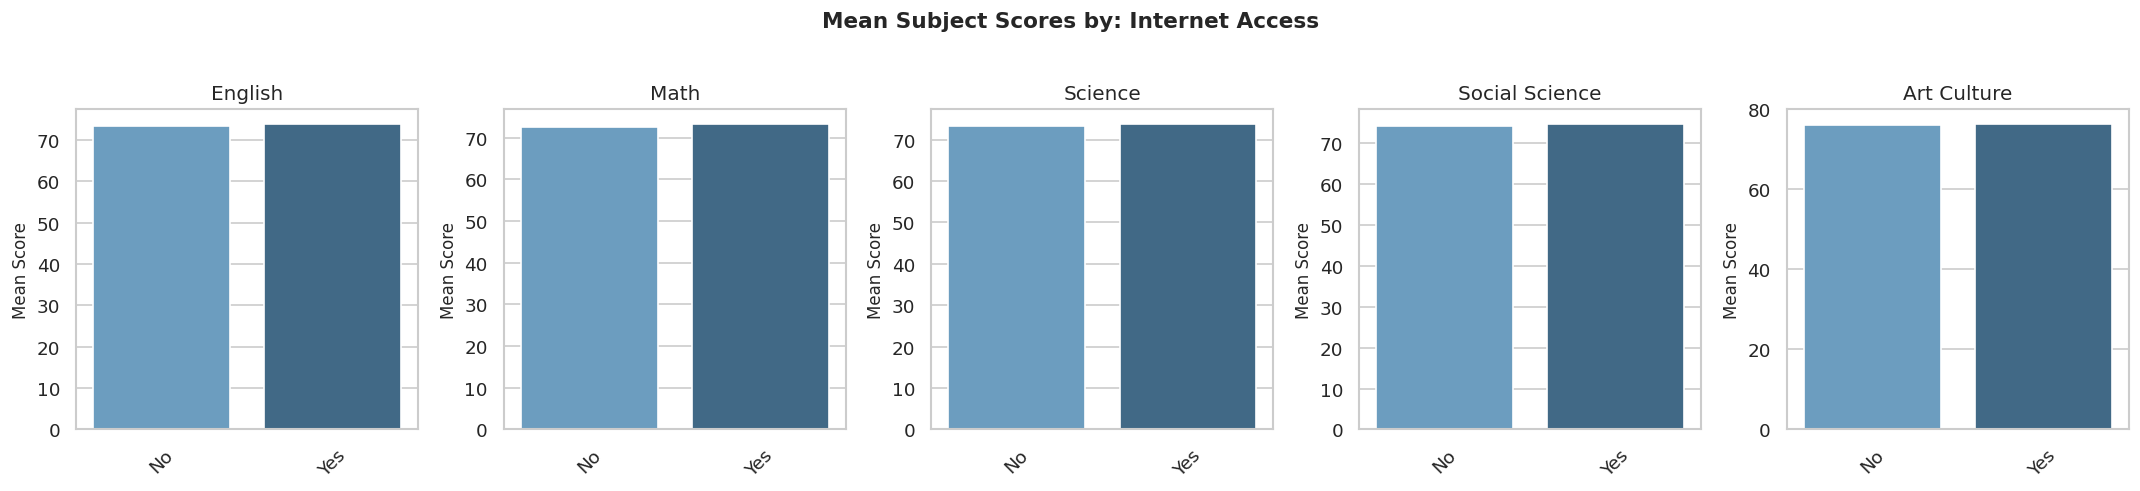

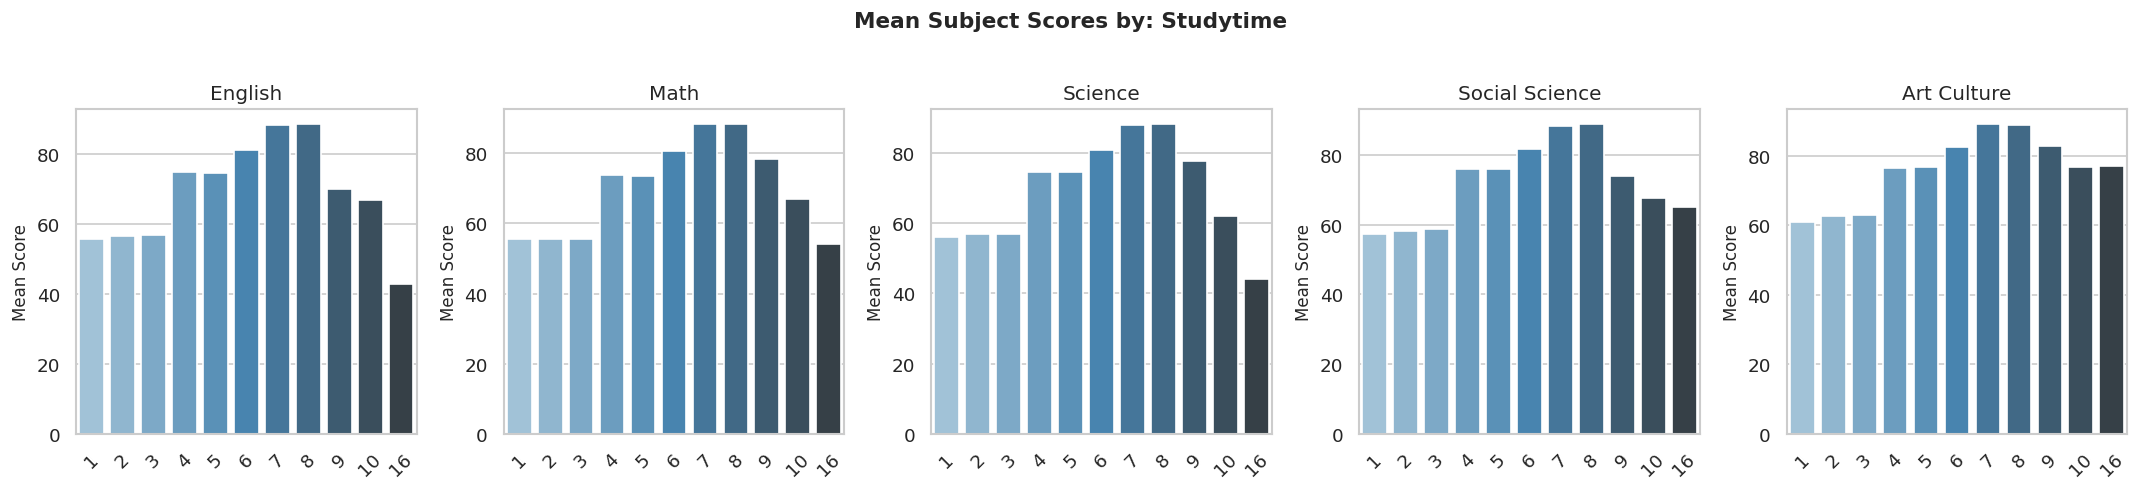

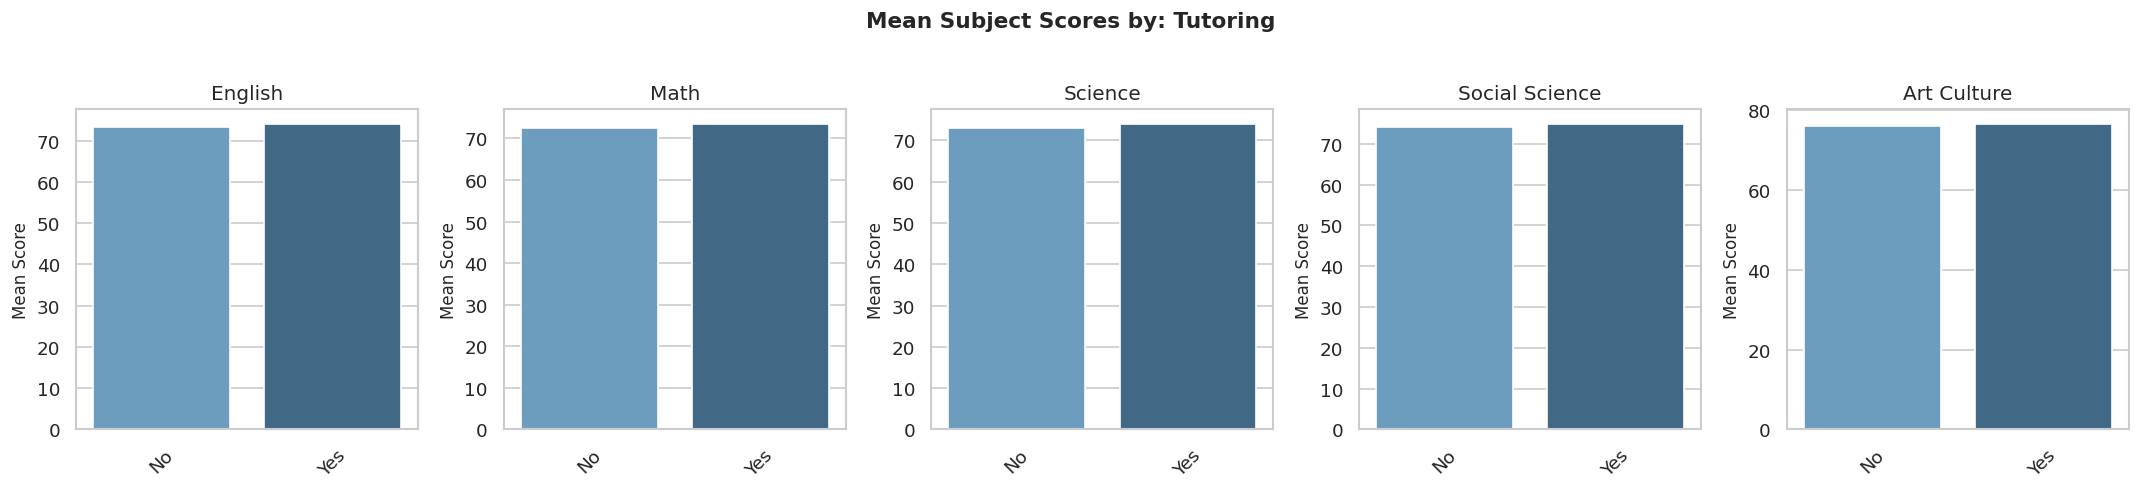

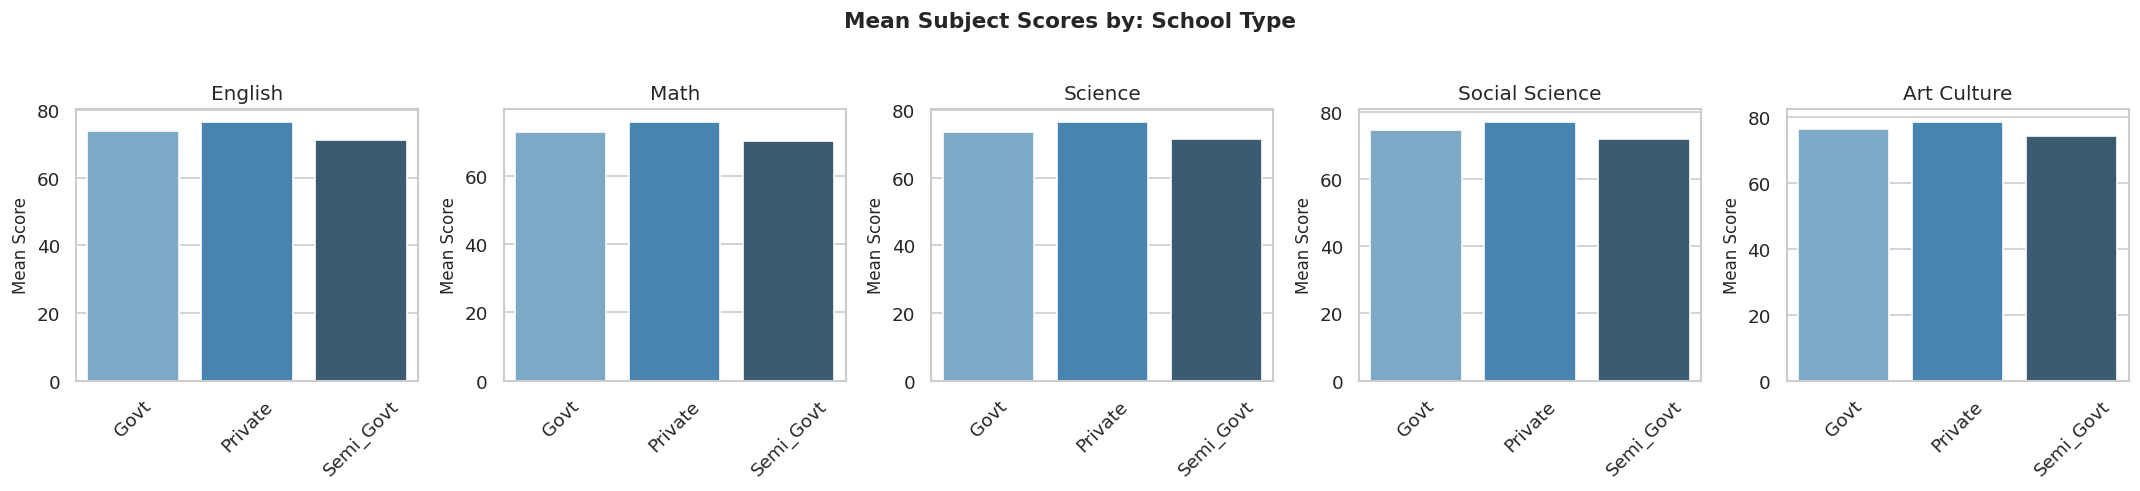

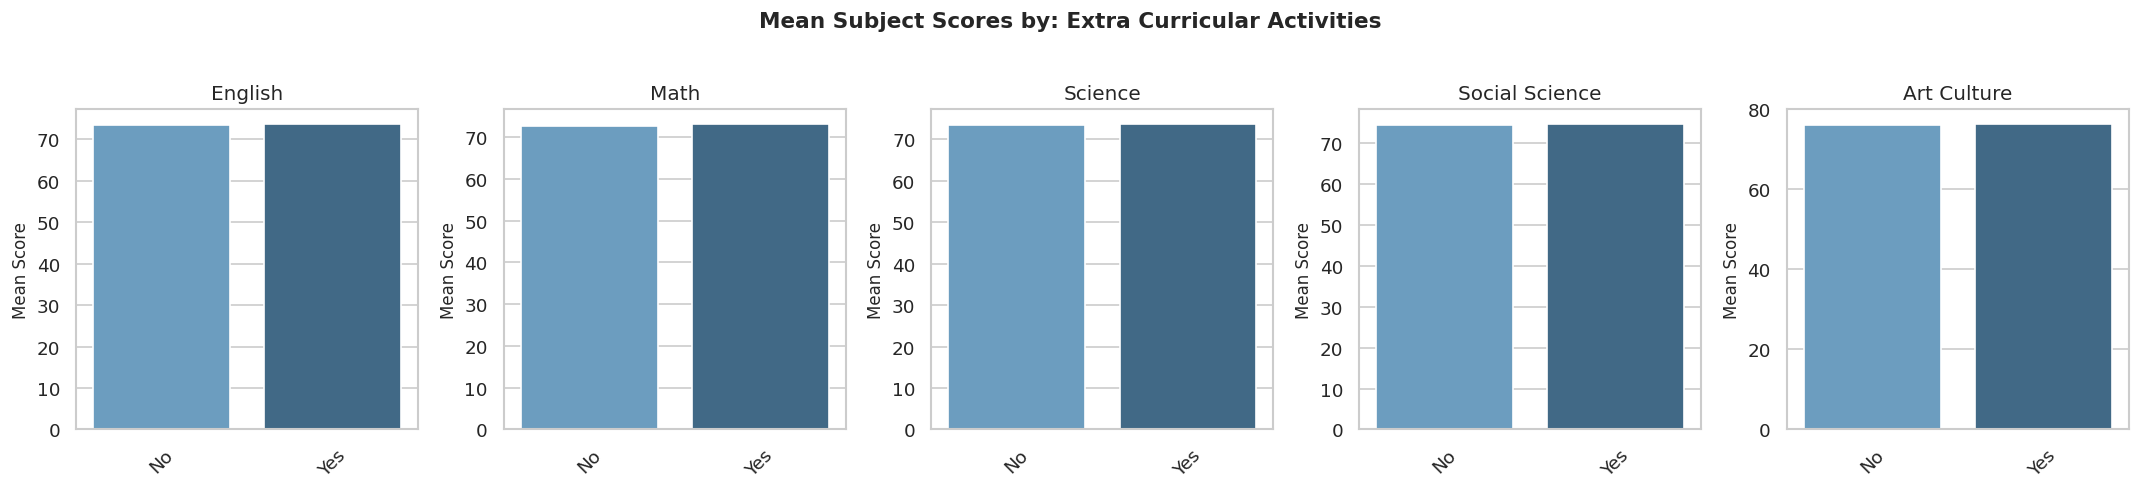

In [8]:
# Mean subject scores broken down by each categorical feature
CATEGORICAL_FEATURES = [
    'age', 'gender', 'location', 'stu_group', 'family_size',
    'mother_education', 'father_education', 'mother_job', 'father_job',
    'guardian', 'parental_involvement', 'internet_access',
    'studytime', 'tutoring', 'school_type', 'extra_curricular_activities'
]

for feature in CATEGORICAL_FEATURES:
    fig, axes = plt.subplots(1, 5, figsize=(18, 4))
    fig.suptitle(f'Mean Subject Scores by: {feature.replace("_", " ").title()}',
                 fontsize=13, fontweight='bold', y=1.02)
    for ax, subject in zip(axes, SCORE_COLS):
        group_means = df.groupby(feature)[subject].mean()
        sns.barplot(x=group_means.index, y=group_means.values, ax=ax, palette='Blues_d')
        ax.set_title(subject.replace('_', ' ').title())
        ax.set_xlabel('')
        ax.set_ylabel('Mean Score')
        ax.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.show()

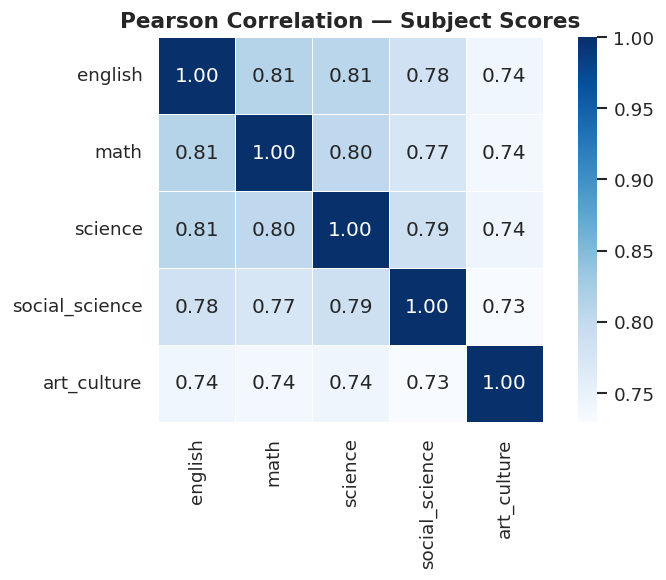

In [9]:
# Pearson correlation heatmap across subject scores
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    df[SCORE_COLS].corr(),
    annot=True, fmt='.2f', cmap='Blues', linewidths=0.5, square=True, ax=ax
)
ax.set_title('Pearson Correlation — Subject Scores', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

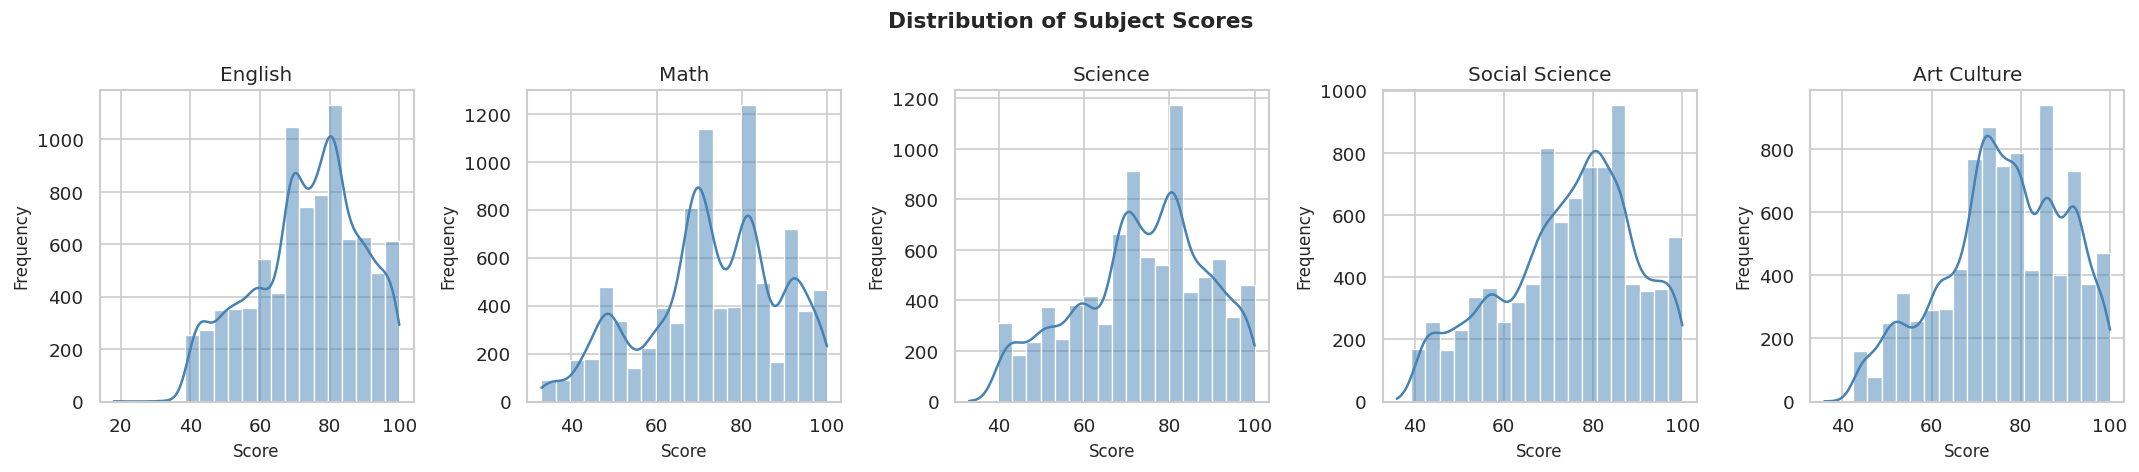

In [10]:
# Score distribution (histogram + KDE) per subject
fig, axes = plt.subplots(1, 5, figsize=(18, 4))
fig.suptitle('Distribution of Subject Scores', fontsize=13, fontweight='bold')
for ax, subject in zip(axes, SCORE_COLS):
    sns.histplot(df[subject], kde=True, ax=ax, color='steelblue', bins=20)
    ax.set_title(subject.replace('_', ' ').title())
    ax.set_xlabel('Score')
    ax.set_ylabel('Frequency')
plt.tight_layout()
plt.show()

In [11]:
# Preprocessing for clustering
# Step 1: drop non-informative columns.
# 'attendance' is excluded because it overlaps strongly with the score
# columns (poor attenders already show up as low scorers) and would create
# multicollinearity without adding independent signal for K-Means.
df_cluster = df.drop(columns=['id', 'full_name', 'attendance']).copy()  # .copy() avoids SettingWithCopyWarning

# Step 2: drop rows with missing values
df_cluster = df_cluster.dropna()
print(f'Rows after dropping nulls: {len(df_cluster)}')

# Step 3: encode categorical columns
#   Truly nominal columns (no natural order) → pd.get_dummies().
#   Using LabelEncoder on these would imply a false ordinality
#   (e.g., school_type=0 < school_type=1) that distorts K-Means distances.
#
#   Ordinal / binary columns stay as integer codes, but each column gets its
#   own LabelEncoder instance stored in `label_encoders` so categories can be
#   recovered later with  label_encoders[col].inverse_transform([...]).

NOMINAL_COLS = [
    'gender', 'location', 'mother_job', 'father_job', 'school_type', 'guardian'
]
ORDINAL_COLS = [
    col for col in df_cluster.columns
    if df_cluster[col].dtype == object and col not in NOMINAL_COLS
]

# One-hot encode nominal columns (drop_first avoids the dummy-variable trap).
# dtype=int ensures 0/1 integer columns instead of bool (pandas ≥2.0 default),
# which prevents dtype errors in StandardScaler and LabelEncoder downstream.
df_cluster = pd.get_dummies(df_cluster, columns=NOMINAL_COLS, drop_first=False, dtype=int)
#
# Ordinal-encode remaining string columns; store each encoder for later use
label_encoders = {}
for col in ORDINAL_COLS:
    le = LabelEncoder()
    df_cluster[col] = le.fit_transform(df_cluster[col])
    label_encoders[col] = le          # kept for inverse_transform if needed

df_cluster.head(3)

Rows after dropping nulls: 8599


,age,stu_group,family_size,mother_education,father_education,parental_involvement,internet_access,studytime,tutoring,extra_curricular_activities,...,mother_job_No,mother_job_Yes,father_job_No,father_job_Yes,school_type_Govt,school_type_Private,school_type_Semi_Govt,guardian_Father,guardian_Mother,guardian_Other
0,16,2,6,6,1,1,1,8,1,1,...,1,0,1,0,0,1,0,1,0,0
1,18,1,6,6,1,1,0,4,0,0,...,1,0,0,1,0,0,1,1,0,0
2,15,1,4,6,6,1,1,5,1,1,...,0,1,0,1,1,0,0,1,0,0


In [12]:
# Step 4: standardise all features (zero mean, unit variance)
scaler = StandardScaler()
scaled_X = scaler.fit_transform(df_cluster)
print(f'Scaled matrix shape: {scaled_X.shape}')
print(f'Mean ~ {scaled_X.mean():.4f}  |  Std ~ {scaled_X.std():.4f}')

Scaled matrix shape: (8599, 32)
Mean ~ 0.0000  |  Std ~ 1.0000


In [13]:
!pip install yellowbrick -q
from yellowbrick.cluster import KElbowVisualizer

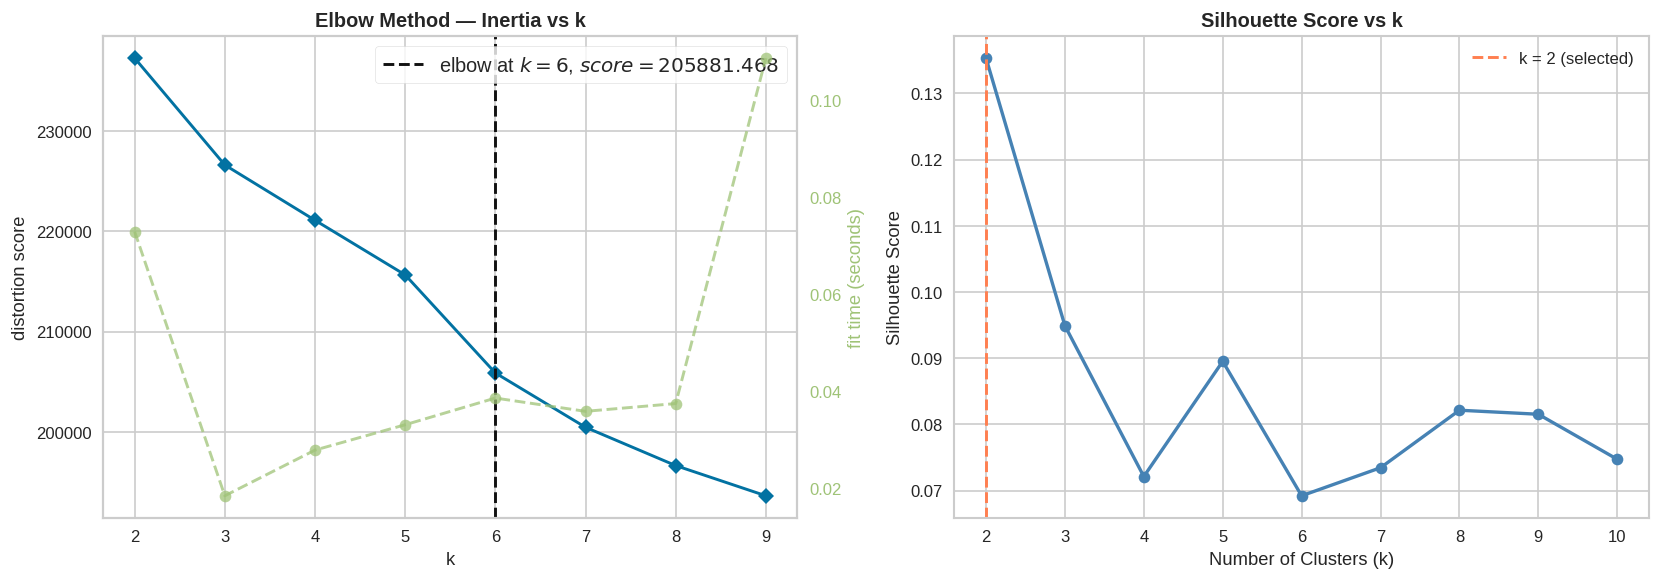

Best silhouette score: 0.1353 at k = 2


In [14]:
# Elbow method + silhouette scores side-by-side to select optimal k
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

elbow_viz = KElbowVisualizer(KMeans(random_state=42), k=(2, 10), ax=axes[0])
elbow_viz.fit(scaled_X)
elbow_viz.finalize()
axes[0].set_title('Elbow Method — Inertia vs k', fontweight='bold')

sil_scores = []
k_range = range(2, 11)
for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    sil_scores.append(silhouette_score(scaled_X, km.fit_predict(scaled_X)))

# Compute best_k BEFORE plotting so the reference line can use it
best_k = list(k_range)[sil_scores.index(max(sil_scores))]

axes[1].plot(list(k_range), sil_scores, marker='o', color='steelblue', linewidth=2)
axes[1].axvline(x=best_k, color='coral', linestyle='--', label=f'k = {best_k} (selected)')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score vs k', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'Best silhouette score: {max(sil_scores):.4f} at k = {best_k}')

In [15]:
# Fit final K-Means model.
# OPTIMAL_K is derived directly from the silhouette-optimal k computed above,
# so the elbow plot, silhouette curve, and model are always in sync.
OPTIMAL_K = best_k   # silhouette-optimal k from the previous cell



kmeans = KMeans(n_clusters=OPTIMAL_K, init='k-means++', random_state=42, n_init=10)
kmeans.fit(scaled_X)
df_cluster['cluster'] = kmeans.labels_

print(f'Silhouette score (k={OPTIMAL_K}): {silhouette_score(scaled_X, kmeans.labels_):.4f}')
print(f'Inertia: {kmeans.inertia_:.2f}')
print('\nCluster sizes:')
print(df_cluster['cluster'].value_counts().sort_index())

Silhouette score (k=2): 0.1353
Inertia: 237229.86

Cluster sizes:
cluster
0    2819
1    5780
Name: count, dtype: int64


In [16]:
# Rank clusters by average score and assign interpretable labels
cluster_means = df_cluster.groupby('cluster')[SCORE_COLS].mean().round(2)
cluster_means['avg_score'] = cluster_means[SCORE_COLS].mean(axis=1).round(2)

rank_order = cluster_means['avg_score'].sort_values(ascending=False)

# Build label map dynamically so it works for any value of OPTIMAL_K,
# not just k=3.  Labels go from best to worst by average score.
_TIER_NAMES = ['High Performers', 'Mid Performers', 'Low Performers']
n_clusters   = len(rank_order)

if n_clusters <= len(_TIER_NAMES):
    # Enough preset names — use the first n and drop the middle ones if k=2
    _selected = [_TIER_NAMES[0]] + _TIER_NAMES[-(n_clusters - 1):]  # High + tail
else:
    # More clusters than preset names: fall back to numeric labels
    _selected = [f'Tier {i+1}' for i in range(n_clusters)]

label_map = {cluster_id: label
             for cluster_id, label in zip(rank_order.index, _selected)}

cluster_means.index = cluster_means.index.map(label_map)
df_cluster['performance_group'] = df_cluster['cluster'].map(label_map)

# Keep CLUSTER_COLORS in sync with however many groups exist
_DEFAULT_COLORS = ['#2ecc71', '#f39c12', '#e74c3c', '#3498db', '#9b59b6']
CLUSTER_COLORS  = {label: _DEFAULT_COLORS[i]
                   for i, label in enumerate(_selected)}

print(f'Clusters found: {n_clusters}  →  labels: {_selected}')
print('=== Mean Subject Scores per Cluster ===')
cluster_means

Clusters found: 2  →  labels: ['High Performers', 'Low Performers']
=== Mean Subject Scores per Cluster ===


,english,math,science,social_science,art_culture,avg_score
cluster,,,,,,
Low Performers,56.06,55.19,56.19,57.80,62.04,57.46
High Performers,82.18,81.60,81.99,82.61,83.18,82.31


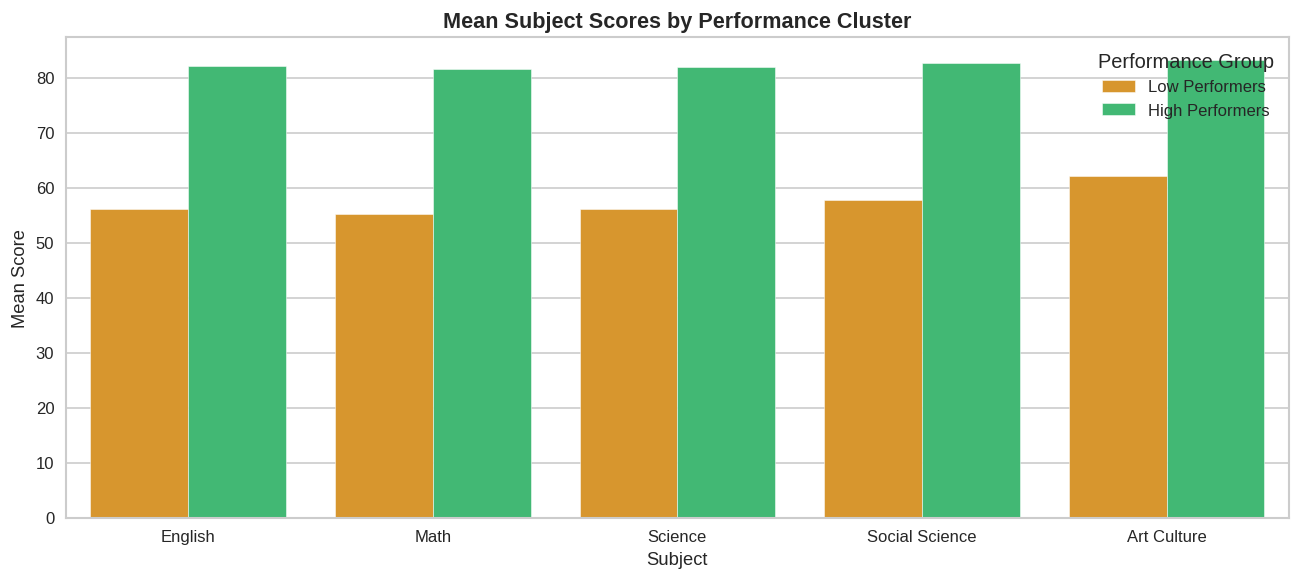

In [17]:
# Grouped bar chart: mean scores per performance group
# CLUSTER_COLORS is built dynamically in the previous cell to match OPTIMAL_K.

cluster_plot = (
    cluster_means[SCORE_COLS]
    .reset_index()
    .melt(id_vars='cluster', var_name='Subject', value_name='Mean Score')
)

fig, ax = plt.subplots(figsize=(11, 5))
sns.barplot(
    data=cluster_plot,
    x='Subject', y='Mean Score', hue='cluster',
    palette=CLUSTER_COLORS, ax=ax
)
ax.set_title('Mean Subject Scores by Performance Cluster', fontsize=13, fontweight='bold')
# Set tick labels after fixing positions to avoid matplotlib FixedFormatter warning
ax.set_xticks(ax.get_xticks())
ax.set_xticklabels([s.replace('_', ' ').title() for s in SCORE_COLS])
ax.legend(title='Performance Group')
plt.tight_layout()
plt.show()

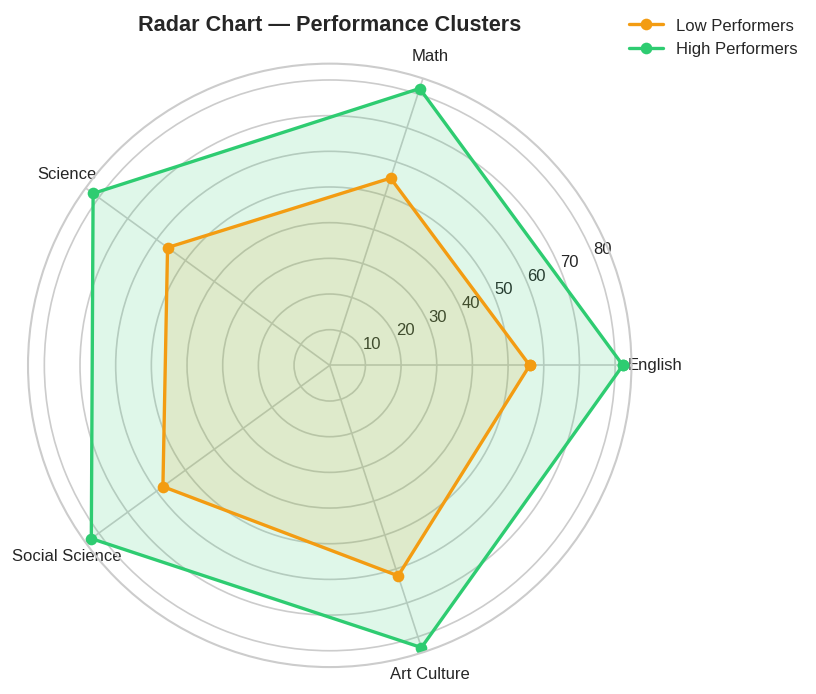

In [18]:
# Radar chart: multi-subject performance profile per cluster
categories = [s.replace('_', ' ').title() for s in SCORE_COLS]
N = len(categories)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
for group, row in cluster_means[SCORE_COLS].iterrows():
    values = row.tolist() + row.tolist()[:1]
    ax.plot(angles, values, 'o-', linewidth=2, label=group, color=CLUSTER_COLORS[group])
    ax.fill(angles, values, alpha=0.15, color=CLUSTER_COLORS[group])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, size=10)
ax.set_title('Radar Chart — Performance Clusters', fontsize=13, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.show()

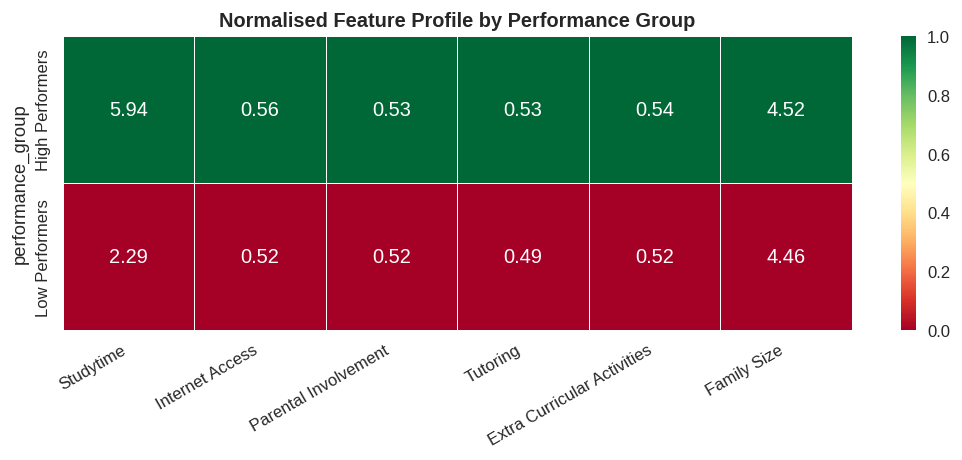

In [19]:
# Feature profile heatmap: compare behavioural features across clusters
PROFILE_FEATURES = [
    'studytime', 'internet_access', 'parental_involvement',
    'tutoring', 'extra_curricular_activities', 'family_size'
]
available = [f for f in PROFILE_FEATURES if f in df_cluster.columns]
profile_df = df_cluster.groupby('performance_group')[available].mean().round(3)

# Normalise 0-1 for visual comparison; annotate with raw encoded means
denom = profile_df.max() - profile_df.min()
denom = denom.replace(0, 1)  # avoid division by zero
profile_norm = (profile_df - profile_df.min()) / denom

fig, ax = plt.subplots(figsize=(9, 4))
sns.heatmap(
    profile_norm, annot=profile_df, fmt='.2f',
    cmap='RdYlGn', linewidths=0.5, ax=ax
)
ax.set_title('Normalised Feature Profile by Performance Group', fontsize=12, fontweight='bold')
ax.set_xticklabels([c.replace('_', ' ').title() for c in available], rotation=30, ha='right')
plt.tight_layout()
plt.show()

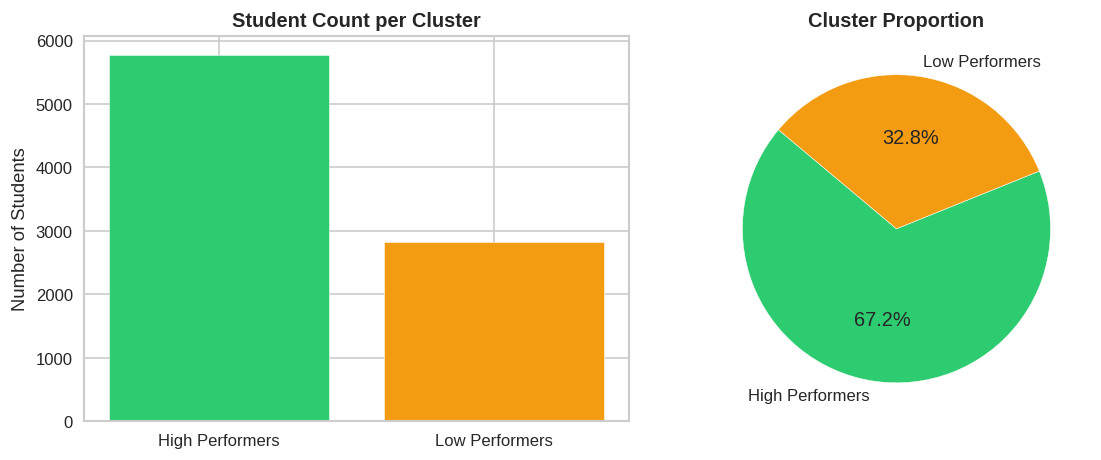

                   Count
performance_group       
High Performers     5780
Low Performers      2819


In [20]:
# Cluster size: bar + pie
size_counts = df_cluster['performance_group'].value_counts()
colors_list = [CLUSTER_COLORS[g] for g in size_counts.index]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].bar(size_counts.index, size_counts.values, color=colors_list, edgecolor='white')
axes[0].set_title('Student Count per Cluster', fontweight='bold')
axes[0].set_ylabel('Number of Students')

axes[1].pie(
    size_counts.values, labels=size_counts.index,
    colors=colors_list, autopct='%1.1f%%', startangle=140
)
axes[1].set_title('Cluster Proportion', fontweight='bold')

plt.tight_layout()
plt.show()
print(size_counts.to_frame(name='Count'))

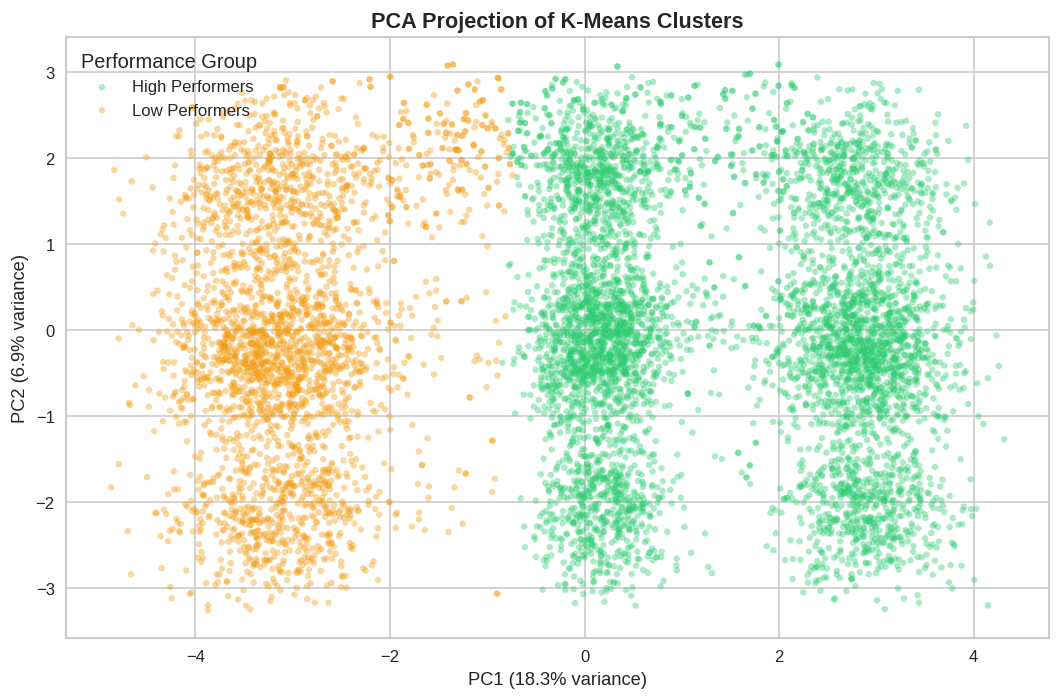

Cumulative variance explained by 2 PCs: 25.2%


In [21]:
# PCA 2-D projection to visualise cluster separability
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(scaled_X)
var_explained = pca.explained_variance_ratio_ * 100

pca_df = pd.DataFrame({
    'PC1': coords[:, 0],
    'PC2': coords[:, 1],
    'performance_group': df_cluster['performance_group'].values
})

fig, ax = plt.subplots(figsize=(9, 6))
for group, color in CLUSTER_COLORS.items():
    mask = pca_df['performance_group'] == group
    ax.scatter(
        pca_df.loc[mask, 'PC1'], pca_df.loc[mask, 'PC2'],
        c=color, label=group, alpha=0.4, s=15, edgecolors='none'
    )

ax.set_xlabel(f'PC1 ({var_explained[0]:.1f}% variance)', fontsize=11)
ax.set_ylabel(f'PC2 ({var_explained[1]:.1f}% variance)', fontsize=11)
ax.set_title('PCA Projection of K-Means Clusters', fontsize=13, fontweight='bold')
ax.legend(title='Performance Group', framealpha=0.8)
plt.tight_layout()
plt.show()
print(f'Cumulative variance explained by 2 PCs: {sum(var_explained):.1f}%')


In [22]:
# ANOVA: test whether cluster means differ significantly for each feature.
#
# Only genuinely numeric (interval-scale) features are included.
# Columns that were ordinal-encoded from strings (stored in `label_encoders`)
# are excluded: F-statistics computed on arbitrary integer codes assigned to
# category labels are numerically valid but substantively misleading.
from scipy import stats

# Score columns are always interval-scale; add raw-numeric behavioural features
# only when they were NOT string-encoded (i.e. they arrived as integers already).
_candidate_behavioural = ['age', 'studytime', 'family_size']
genuinely_numeric = SCORE_COLS + [
    col for col in _candidate_behavioural if col not in label_encoders
]

groups = [df_cluster[df_cluster['performance_group'] == g] for g in CLUSTER_COLORS]

print(f"{'Feature':<28} {'F-statistic':>12} {'p-value':>12}  Significant?")
print('-' * 62)
for feat in genuinely_numeric:
    samples = [g[feat].dropna() for g in groups]
    f_stat, p_val = stats.f_oneway(*samples)
    sig = 'Yes ***' if p_val < 0.001 else ('Yes *' if p_val < 0.05 else 'No')
    print(f"{feat:<28} {f_stat:>12.2f} {p_val:>12.4f}  {sig}")

Feature                       F-statistic      p-value  Significant?
--------------------------------------------------------------
english                          15158.28       0.0000  Yes ***
math                             13669.79       0.0000  Yes ***
science                          15397.29       0.0000  Yes ***
social_science                   13284.63       0.0000  Yes ***
art_culture                       9738.20       0.0000  Yes ***
age                                  0.17       0.6816  No
studytime                        13639.42       0.0000  Yes ***
family_size                          2.27       0.1320  No


In [23]:
# Final results summary
final_sil = silhouette_score(scaled_X, kmeans.labels_)
cluster_sizes = df_cluster['performance_group'].value_counts()
cluster_avg = df_cluster.groupby('performance_group')[SCORE_COLS].mean().round(1)
cluster_avg['Average'] = cluster_avg.mean(axis=1).round(1)

print('=' * 55)
print('  RESEARCH SUMMARY — Student Performance Clustering')
print('=' * 55)
print(f'  Dataset        : {len(df_cluster):,} students, {scaled_X.shape[1]} features')
print(f'  Algorithm      : K-Means (k={OPTIMAL_K}, init=k-means++)')
print(f'  Silhouette Score: {final_sil:.4f}')
print()
print('  Cluster Sizes')
for grp, cnt in cluster_sizes.items():
    print(f'    {grp:<18}: {cnt:>5} students ({cnt/len(df_cluster)*100:.1f}%)')
print()
print('  Mean Subject Scores per Cluster')
print(cluster_avg[['Average'] + SCORE_COLS].to_string())
print('=' * 55)


  RESEARCH SUMMARY — Student Performance Clustering
  Dataset        : 8,599 students, 32 features
  Algorithm      : K-Means (k=2, init=k-means++)
  Silhouette Score: 0.1353

  Cluster Sizes
    High Performers   :  5780 students (67.2%)
    Low Performers    :  2819 students (32.8%)

  Mean Subject Scores per Cluster
                   Average  english  math  science  social_science  art_culture
performance_group                                                              
High Performers       82.3     82.2  81.6     82.0            82.6         83.2
Low Performers        57.5     56.1  55.2     56.2            57.8         62.0
